# 04 — Pooled Linear-Regression Trend System

## tl;dr

The full five-market portfolio produced 2/4 positive validation folds and a session-weighted annualized return of -4.2% after placeholder costs. It is a functioning point-in-time system, but it does **not** yet demonstrate stable edge. The sealed holdout was not loaded.

## Context & Methods

A pooled Ridge linear regression is trained across CL, HG, NQ, ZN and ZT. It forecasts five-session volatility-normalized forward return using 20 trend features. Every fold fits its imputer, scaler, symbol effects and regression coefficients only on expanding training data whose labels were already available.

### Key assumptions

- Four fixed walk-forward validation folds with a five-session embargo.
- One-session execution delay; daily refresh keeps holding below five sessions.
- Trailing exponentially weighted/shrunk covariance sizing.
- 10% volatility target, 2× gross ceiling and ±25% net limit.
- 3.5 bps one-way placeholder cost and sequential drawdown controls.
- ES and GC remain excluded until development history exists.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from systematic_research.ml_trend import ML_TREND_FEATURES
ROOT = Path.cwd().parent if Path.cwd().name == 'outputs' else Path.cwd()
PORT = ROOT / 'data/processed/portfolios'
summary = pd.read_csv(PORT / 'ml_trend_walk_forward_summary.csv')
diagnostics = pd.read_csv(PORT / 'ml_trend_prediction_diagnostics.csv')
coefficients = pd.read_csv(PORT / 'ml_trend_fold_coefficients.csv')
pd.DataFrame({'feature': ML_TREND_FEATURES})

,feature
0,momentum_2s
1,momentum_5s
2,momentum_10s
3,momentum_20s
4,momentum_60s
5,momentum_120s
6,standardized_return_20s
7,standardized_return_60s
8,price_to_sma_20s
9,price_to_sma_60s


## Data

Only approved development-session features and separately stored labels are used.

In [2]:
summary.round(4)

,fold,sessions,annualized_return,annualized_volatility,sharpe,maximum_drawdown,average_gross,average_net,average_daily_turnover
0,1,63,0.1346,0.0969,1.3882,-0.0371,1.4214,-0.0668,0.2791
1,2,63,-0.2197,0.1106,-1.9870,-0.0705,1.5845,-0.1890,0.2326
2,3,63,0.0545,0.0684,0.7970,-0.0253,0.6118,-0.1456,0.0540
3,4,37,-0.2060,0.1558,-1.3221,-0.0638,1.0485,-0.1786,0.1315


## Results

In [3]:
diagnostics.pivot(index='symbol', columns='fold', values='spearman_ic').round(3)

fold,1,2,3,4
symbol,,,,
CLU6,0.143,0.085,0.389,0.552
HGU6,0.178,0.385,0.453,-0.037
NQU6,-0.270,0.042,0.256,-0.143
ZNU6,0.184,-0.416,0.106,0.106
ZTU6,0.135,-0.300,0.007,-0.526


In [4]:
numeric = coefficients[coefficients['feature'].str.startswith('numeric__')].copy()
numeric['absolute_coefficient'] = numeric['coefficient'].abs()
stability = numeric.groupby('feature').agg(
    mean_absolute_coefficient=('absolute_coefficient', 'mean'),
    minimum_coefficient=('coefficient', 'min'),
    maximum_coefficient=('coefficient', 'max'),
).sort_values('mean_absolute_coefficient', ascending=False)
stability.head(12).round(4)

,mean_absolute_coefficient,minimum_coefficient,maximum_coefficient
feature,,,
numeric__missingindicator_momentum_60s,0.3710,0.3645,0.3745
numeric__missingindicator_standardized_return_60s,0.3710,0.3645,0.3745
numeric__trend_slope_120s,0.2336,-0.2618,-0.2140
numeric__missingindicator_trend_efficiency_60s,0.1842,-0.1865,-0.1820
numeric__missingindicator_trend_r_squared_60s,0.1842,-0.1865,-0.1820
numeric__missingindicator_trend_slope_60s,0.1842,-0.1865,-0.1820
numeric__missingindicator_ema_gap_10_60s,0.1842,-0.1865,-0.1820
numeric__missingindicator_price_to_sma_60s,0.1842,-0.1865,-0.1820
numeric__missingindicator_momentum_120s,0.1619,0.1519,0.1770


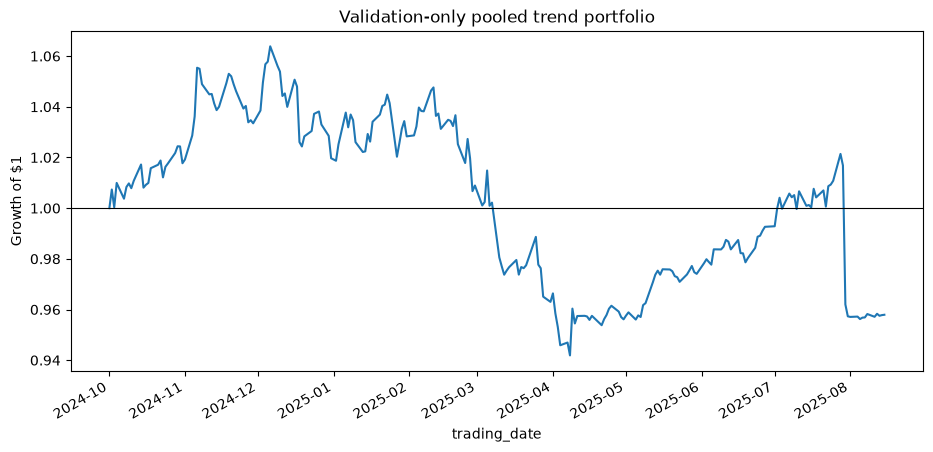

In [5]:
returns = pd.read_parquet(PORT / 'ml_trend_portfolio_returns.parquet')['net_return']
folds = pd.read_csv(ROOT / 'outputs/development_walk_forward_folds.csv')
mask = pd.Series(False, index=returns.index)
for row in folds.itertuples():
    mask.loc[pd.Timestamp(row.validation_start):pd.Timestamp(row.validation_end)] = True
equity = (1 + returns[mask]).cumprod()
ax = equity.plot(figsize=(11, 5), title='Validation-only pooled trend portfolio')
ax.axhline(1.0, color='black', lw=.8); ax.set_ylabel('Growth of $1'); plt.show()

## Takeaways

1. The model and portfolio plumbing are complete and reproducible, but performance is not stable enough to graduate.
2. CL and HG show the most consistent forecast association; rates and NQ are less stable.
3. The strongest coefficient families are 120-session slope, 120-session moving-average distance, 60-session trend fit and the 10/60 EMA gap.
4. The next justified model test is instrument–feature interactions or separate asset-class linear models combined by one portfolio allocator—not more arbitrary indicators.
5. The design must be frozen before any sealed-holdout evaluation.